# **FLUXO DE MODELAGEM — VALIDAÇÃO SIMPLES + CRUZADA**
### *Case: Risco de Crédito (Home Credit Default Risk)*

### **Bibliotecas**

In [1]:
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint, uniform, loguniform

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, brier_score_loss,
                             confusion_matrix, classification_report)
from sklearn.calibration import calibration_curve
import shap

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = [10, 6]
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", None)

import sys
from pathlib import Path
NB_DIR = Path.cwd()
if not (NB_DIR / "train.py").exists():
    for cand in [NB_DIR / "Model", NB_DIR.parent / "Model", NB_DIR.parent]:
        if (cand / "train.py").exists():
            NB_DIR = cand
            break
DATA_PIPELINE_DIR = NB_DIR.parent / "DataPipeline"
sys.path.insert(0, str(NB_DIR))
sys.path.insert(0, str(DATA_PIPELINE_DIR))

from train import load_config, DEFAULT_CONFIG_PATH
from utils import get_database_engine

### **Parâmetros centralizados**

In [2]:
# Config carregada do config_model.json (fonte unica) + conexao via utils.
config = load_config(DEFAULT_CONFIG_PATH)
CONFIG = {
    "abt_table":     config["metadata"]["abt_table"],
    "random_state":  config["validation"]["random_state"],
    "test_size":     config["validation"]["test_size"],
    "n_folds":       config["validation"]["n_folds"],
    "n_iter":        config["validation"]["n_iter"],
    "amostra_busca": config["validation"]["sample_search"],
}
SEED = CONFIG["random_state"]
engine = get_database_engine()   # Engine do SQLAlchemy (sem conn_str chumbado, sem warning do pandas)
print("Config:", CONFIG)

[CONEXÃO] Execução isolada detectada (Local/Notebook). Engine SQLAlchemy em 'postgres'.
Config: {'abt_table': 'application_abt', 'random_state': 123, 'test_size': 0.2, 'n_folds': 5, 'n_iter': 8, 'amostra_busca': 100000}


### **Leitura da base de dados (ABT limpa)**

In [3]:
print("Carregando a ABT do PostgreSQL...")
dados = pd.read_sql(f'SELECT * FROM {CONFIG["abt_table"]}', engine)
print(f"Dimensoes: {dados.shape[0]:,} linhas x {dados.shape[1]} colunas")
dados.head()

Carregando a ABT do PostgreSQL...
Dimensoes: 307,511 linhas x 44 colunas


,sk_id_curr,target,ext_source_1,ext_source_2,ext_source_3,ext_source_mean,region_rating_client_w_city,days_last_phone_change,days_id_publish,days_registration,reg_city_not_work_city,reg_city_not_live_city,live_city_not_work_city,has_car,own_car_age,def_60_cnt_social_circle,amt_req_credit_bureau_year,cnt_children,cnt_fam_members,amt_income_total,amt_credit,amt_annuity,occupation_type,organization_type,name_income_type,name_education_type,code_gender,age,years_employed,days_employed_anom,fe_credit_income_percent,fe_annuity_income_percent,has_prev_app,prev_refused_rate,has_bureau,bureau_avg_days_credit,bureau_last_days_credit,bureau_active_rate,bureau_active_count,bureau_closed_rate,bureau_debt_credit_ratio,bureau_overdue_count,has_installments_history,inst_late_payment_rate
0,100014,0,0.319760,0.651862,0.363945,0.445189,2,-844.0,-738,-4427.0,0,0,0,0,0.0,0.0,0.0,1,3.0,112500.0,652500.0,21177.0,Core staff,Medicine,Working,Higher education,F,27.917864,1.859001,0,5.800000,0.188240,1,0.00,1,-1095.375000,-376.0,0.250000,2,0.750000,0.277741,0,1,0.421053
1,100082,0,0.357707,0.686505,0.394495,0.479569,2,-1003.0,-3656,-1377.0,0,0,0,0,0.0,0.0,2.0,2,4.0,180000.0,450000.0,21109.5,Laborers,Business Entity Type 3,Commercial associate,Higher education,M,32.878850,7.786448,0,2.500000,0.117275,1,0.60,1,-1133.411765,-65.0,0.294118,5,0.705882,0.229436,0,1,0.049587
2,100094,0,0.505998,0.582735,0.452534,0.513756,2,-260.0,-3442,-12623.0,0,0,0,0,0.0,0.0,0.0,0,1.0,108000.0,113760.0,5301.0,Unknown,XNA,Pensioner,Higher education,F,62.792608,0.000000,1,1.053333,0.049083,1,0.00,1,-527.250000,-246.0,0.750000,3,0.250000,0.715012,0,1,0.000000
3,100123,0,0.505998,0.399366,0.673830,0.526398,3,-1689.0,-4036,-3917.0,0,0,0,0,0.0,0.0,2.0,0,1.0,103500.0,675000.0,19737.0,Security staff,Medicine,Working,Secondary / secondary special,F,64.939083,23.178645,0,6.521739,0.190696,1,0.25,1,-1618.833333,-62.0,0.500000,3,0.500000,0.430870,0,1,0.000000
4,100131,0,0.339403,0.707972,0.452534,0.499970,1,-734.0,-4802,-7953.0,0,0,0,0,0.0,1.0,4.0,0,1.0,270000.0,891072.0,45625.5,Realty agents,Other,Commercial associate,Secondary / secondary special,F,37.864476,3.200548,0,3.300267,0.168983,1,0.00,1,-690.500000,-506.0,1.000000,2,0.000000,0.998179,0,1,0.016129


### **Etapa 1: Especificação de variáveis explicativas e variável resposta**

Separamos as explicativas em **quantitativas** e **qualitativas** (o pré-processamento é diferente para cada
grupo) e definimos a resposta. `sk_id_curr` é identificador e sai das explicativas.

In [4]:
resposta = "target"
ident = ["sk_id_curr"]

# Qualitativas (categóricas) e quantitativas (numéricas), derivadas automaticamente do schema da ABT
lista_X_quali = dados.drop(columns=ident + [resposta]).select_dtypes(include=["object"]).columns.tolist()
lista_X_quanti = [c for c in dados.columns if c not in ident + [resposta] + lista_X_quali]

print(f"Variaveis quantitativas ({len(lista_X_quanti)}):\n{lista_X_quanti}\n")
print(f"Variaveis qualitativas ({len(lista_X_quali)}):\n{lista_X_quali}")

y = dados[resposta].astype(int)
X = dados[lista_X_quanti + lista_X_quali]

Variaveis quantitativas (37):
['ext_source_1', 'ext_source_2', 'ext_source_3', 'ext_source_mean', 'region_rating_client_w_city', 'days_last_phone_change', 'days_id_publish', 'days_registration', 'reg_city_not_work_city', 'reg_city_not_live_city', 'live_city_not_work_city', 'has_car', 'own_car_age', 'def_60_cnt_social_circle', 'amt_req_credit_bureau_year', 'cnt_children', 'cnt_fam_members', 'amt_income_total', 'amt_credit', 'amt_annuity', 'age', 'years_employed', 'days_employed_anom', 'fe_credit_income_percent', 'fe_annuity_income_percent', 'has_prev_app', 'prev_refused_rate', 'has_bureau', 'bureau_avg_days_credit', 'bureau_last_days_credit', 'bureau_active_rate', 'bureau_active_count', 'bureau_closed_rate', 'bureau_debt_credit_ratio', 'bureau_overdue_count', 'has_installments_history', 'inst_late_payment_rate']

Variaveis qualitativas (5):
['occupation_type', 'organization_type', 'name_income_type', 'name_education_type', 'code_gender']


### **Etapa 2: Divisão de treino e teste externo**

Holdout de **20% estratificado** pelo target (preserva os ~8% de inadimplentes nos dois lados). O teste
externo fica reservado e só é usado nas Etapas 6/8 — nunca na construção.

In [5]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=CONFIG["test_size"], stratify=y, random_state=SEED)

print(f"Treino: {X_treino.shape[0]:,} linhas | inadimplencia: {y_treino.mean()*100:.2f}%")
print(f"Teste : {X_teste.shape[0]:,} linhas | inadimplencia: {y_teste.mean()*100:.2f}%")

Treino: 246,008 linhas | inadimplencia: 8.07%
Teste : 61,503 linhas | inadimplencia: 8.07%


> ### Análise — Etapas 1 e 2 (variáveis e divisão treino/teste)
>
> Separamos as explicativas em **quantitativas (37)** e **qualitativas (5)** porque cada
> grupo pede um pré-processamento diferente; e reservamos **20% para teste externo, estratificado**, para
> medir generalização em dados que o modelo nunca vê (sem vazamento).

### **Etapa 3: Pré-processamento de variáveis explicativas**

Padronização (`StandardScaler`) nas quantitativas + codificação **one-hot** (`drop="first"`) nas
qualitativas. O pré-processador é **ajustado só no treino** (`fit_transform`) e **apenas aplicado** no teste
(`transform`) — o teste externo nunca participa da construção.

In [6]:
preprocessador = ColumnTransformer(transformers=[
    ("quanti", StandardScaler(), lista_X_quanti),
    ("quali", OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore"), lista_X_quali),
])

# Ajuste + aplicacao no treino
X_treino_tratada = preprocessador.fit_transform(X_treino)
nomes_quali = list(preprocessador.named_transformers_["quali"].get_feature_names_out(lista_X_quali)) if lista_X_quali else []
nomes_variaveis = list(lista_X_quanti) + nomes_quali

# LightGBM/XGBoost nao aceitam caracteres especiais (espaco, / : - etc.) nos nomes de coluna que o one-hot
# gera a partir dos valores das categorias -> normaliza para [A-Za-z0-9_], preservando a unicidade
import re
def _limpa_nome(n):
    return re.sub(r"[^0-9A-Za-z_]+", "_", str(n)).strip("_") or "col"
_seen, nomes_limpos = {}, []
for _n in nomes_variaveis:
    _b = _limpa_nome(_n)
    _seen[_b] = _seen.get(_b, -1) + 1
    nomes_limpos.append(_b if _seen[_b] == 0 else f"{_b}_{_seen[_b]}")
nomes_variaveis = nomes_limpos

X_treino_tratada = pd.DataFrame(X_treino_tratada, columns=nomes_variaveis, index=X_treino.index)

# Apenas aplicacao no teste externo (mesmo objeto, agora com transform)
X_teste_tratada = pd.DataFrame(preprocessador.transform(X_teste), columns=nomes_variaveis, index=X_teste.index)

print(f"Matriz tratada: {X_treino_tratada.shape[1]} colunas (após one-hot)")
X_treino_tratada.head()

Matriz tratada: 106 colunas (após one-hot)


,ext_source_1,ext_source_2,ext_source_3,ext_source_mean,region_rating_client_w_city,days_last_phone_change,days_id_publish,days_registration,reg_city_not_work_city,reg_city_not_live_city,live_city_not_work_city,has_car,own_car_age,def_60_cnt_social_circle,amt_req_credit_bureau_year,cnt_children,cnt_fam_members,amt_income_total,amt_credit,amt_annuity,age,years_employed,days_employed_anom,fe_credit_income_percent,fe_annuity_income_percent,has_prev_app,prev_refused_rate,has_bureau,bureau_avg_days_credit,bureau_last_days_credit,bureau_active_rate,bureau_active_count,bureau_closed_rate,bureau_debt_credit_ratio,bureau_overdue_count,has_installments_history,inst_late_payment_rate,occupation_type_Cleaning_staff,occupation_type_Cooking_staff,occupation_type_Core_staff,occupation_type_Drivers,occupation_type_HR_staff,occupation_type_High_skill_tech_staff,occupation_type_IT_staff,occupation_type_Laborers,occupation_type_Low_skill_Laborers,occupation_type_Managers,occupation_type_Medicine_staff,occupation_type_Private_service_staff,occupation_type_Realty_agents,occupation_type_Sales_staff,occupation_type_Secretaries,occupation_type_Security_staff,occupation_type_Unknown,occupation_type_Waiters_barmen_staff,organization_type_Bank,organization_type_Business_Entity_Type_1,organization_type_Business_Entity_Type_2,organization_type_Business_Entity_Type_3,organization_type_Construction,organization_type_Electricity,organization_type_Emergency,organization_type_Government,organization_type_Hotel,organization_type_Housing,organization_type_Industry_type_1,organization_type_Industry_type_11,organization_type_Industry_type_3,organization_type_Industry_type_4,organization_type_Industry_type_5,organization_type_Industry_type_7,organization_type_Industry_type_9,organization_type_Insurance,organization_type_Kindergarten,organization_type_Medicine,organization_type_Military,organization_type_Other,organization_type_Other_low_freq,organization_type_Police,organization_type_Postal,organization_type_Restaurant,organization_type_School,organization_type_Security,organization_type_Security_Ministries,organization_type_Self_employed,organization_type_Services,organization_type_Telecom,organization_type_Trade_type_2,organization_type_Trade_type_3,organization_type_Trade_type_6,organization_type_Trade_type_7,organization_type_Transport_type_2,organization_type_Transport_type_3,organization_type_Transport_type_4,organization_type_University,organization_type_XNA,name_income_type_Other_low_freq,name_income_type_Pensioner,name_income_type_State_servant,name_income_type_Working,name_education_type_Higher_education,name_education_type_Incomplete_higher,name_education_type_Lower_secondary,name_education_type_Secondary_secondary_special,code_gender_M,code_gender_Unknown
305615,1.172436,1.059791,0.583501,1.442429,-2.054253,-0.675322,-1.210752,0.910608,-0.547208,-0.290960,-0.467576,-0.717144,-0.454727,-0.274569,0.730493,3.576842,3.126510,1.255690,-0.452292,-0.593313,-0.465752,1.216717,-0.468667,-0.901866,-1.197254,0.238506,0.425318,0.409237,-0.735927,0.753068,-0.011841,2.901816,0.428616,-0.088365,-0.09981,0.233854,-0.629551,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
152475,-1.513182,0.319424,0.111143,-0.402627,-0.064096,0.214975,0.960984,1.281841,1.827459,3.436895,2.138689,-0.717144,-0.454727,-0.274569,-0.884978,0.807497,0.930589,-0.481071,-1.040562,-0.864246,-1.481726,-0.293688,-0.468667,-0.945047,-0.698071,0.238506,1.262420,-2.443571,1.438312,0.796672,-1.104978,-0.975907,-1.421289,-0.526921,-0.09981,0.233854,-0.629551,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0

In [7]:
n_amostra = min(CONFIG["amostra_busca"], len(X_treino_tratada))
X_busca, _, y_busca, _ = train_test_split(
    X_treino_tratada, y_treino, train_size=n_amostra, stratify=y_treino, random_state=SEED)
print(f"Amostra de busca: {X_busca.shape[0]:,} linhas ({y_busca.mean()*100:.2f}% inadimplentes)")

Amostra de busca: 100,000 linhas (8.07% inadimplentes)


> ### Análise — Etapa 3 (pré-processamento e amostra de busca)
>
> Padronizamos as numéricas (`StandardScaler`) porque modelos lineares e sensíveis a
> escala precisam disso, e aplicamos **one-hot** nas categóricas para não impor uma ordem falsa. O modelo final é retreinado na base completa.
> 
> A amostra é grande o bastante para selecionar bem os modelos sem limitar o modelo final.

### **Etapa 4: Definição dos algoritmos e intervalos de busca de hiperparâmetros**

Os regressores do fluxo original viram seus equivalentes classificadores. O
desbalanceamento é tratado com `class_weight="balanced"` (ou `scale_pos_weight` no XGBoost). Em vez de testar
muitos algoritmos redundantes, usamos um **conjunto curado de 4** que cobre as famílias relevantes para dados
tabulares de crédito — **linear regularizado (Logística L2)**, **bagging (Floresta Aleatória)** e **boosting
(XGBoost e LightGBM)**.

As faixas de hiperparâmetros dos *boostings* foram concentradas na **região regularizada** (learning rate
baixo, folhas maiores, L2 ≥ 0,5) — assim a busca não gasta iterações em configs que overfittam, dando ao
boosting uma comparação justa contra a logística.

In [8]:
# Peso da classe positiva para o XGBoost (equivalente ao class_weight='balanced')
spw = (y_treino == 0).sum() / (y_treino == 1).sum()

algoritmos = {

    'REGRESSÃO LOGÍSTICA (L2)': (
        LogisticRegression(penalty="l2", solver="lbfgs", class_weight="balanced",
                           max_iter=1000, random_state=SEED), {
        'C': loguniform(1e-3, 1e2)                    # Inverso da força da regularização L2
    }),

    'FLORESTA ALEATÓRIA': (
        RandomForestClassifier(class_weight="balanced", n_jobs=-1, random_state=SEED), {
        'n_estimators': randint(100, 200),            # Qtde. de árvores (limitado p/ custo)
        'max_depth': randint(6, 14),                  # Profundidade máxima
        'min_samples_leaf': randint(30, 120),         # Tamanho mínimo de folha
        'max_features': ['sqrt', 'log2']              # Variáveis por split (descorrelaciona)
    }),

    'XGBOOST': (
        XGBClassifier(scale_pos_weight=spw, tree_method="hist", eval_metric="logloss",
                     n_jobs=-1, random_state=SEED), {
        'n_estimators': randint(150, 400),            # Qtde. de árvores
        'learning_rate': uniform(0.02, 0.08),         # Taxa de aprendizado (região baixa, generaliza melhor)
        'max_depth': randint(3, 8),                   # Profundidade (árvores mais rasas)
        'min_child_weight': randint(3, 20),           # Peso mínimo por folha (regularização)
        'subsample': uniform(0.6, 0.4),               # Proporção de linhas por árvore
        'colsample_bytree': uniform(0.6, 0.4),        # Proporção de colunas por árvore
        'reg_lambda': uniform(0.5, 2.5)               # Regularização L2 (mínima 0.5)
    }),

    'LIGHTGBM': (
        LGBMClassifier(class_weight="balanced", n_jobs=-1, random_state=SEED, verbosity=-1), {
        'n_estimators': randint(150, 400),            # Qtde. de árvores
        'learning_rate': uniform(0.02, 0.08),         # Taxa de aprendizado (região baixa, generaliza melhor)
        'num_leaves': randint(15, 48),                # Complexidade de cada árvore (menor = menos overfit)
        'max_depth': randint(3, 9),                   # Profundidade
        'min_child_samples': randint(50, 300),        # Mínimo por folha (folhas grandes = menos overfit)
        'colsample_bytree': uniform(0.6, 0.4),        # Proporção de colunas por árvore
        'reg_lambda': uniform(0.5, 2.5)               # Regularização L2 (mínima 0.5)
    }),
}
print(f"{len(algoritmos)} algoritmos definidos | scale_pos_weight (XGBoost) = {spw:.2f}")

4 algoritmos definidos | scale_pos_weight (XGBoost) = 11.39


### **Etapa 5: Construção de modelos usando validação cruzada, busca aleatória e teste externo**

Para cada algoritmo: **busca aleatória** (`RandomizedSearchCV`) com **validação cruzada estratificada
(k=5)** sobre a amostra de busca, usando **AUC** como métrica. Guardamos, para cada configuração testada:
- **AUC de treino** e **AUC de teste interno** (validação cruzada) → o `return_train_score=True` permite medir overfitting;
- **AUC de teste externo** (modelo re-treinado na amostra e aplicado ao holdout);
- as **variações treino→interno** e **treino→externo** (quanto o modelo "cai" fora do treino = overfitting).

In [9]:
kf = StratifiedKFold(n_splits=CONFIG["n_folds"], shuffle=True, random_state=SEED)
qtd_iteracoes = CONFIG["n_iter"]

resultados = []
contador_modelos = 0

for nome_algoritmo, (classe_algoritmo, hiperparametros) in algoritmos.items():
    inicio = time.time()

    busca = RandomizedSearchCV(
        estimator=classe_algoritmo,
        param_distributions=hiperparametros,
        n_iter=1 if not hiperparametros else qtd_iteracoes,
        scoring="roc_auc",
        cv=kf,
        return_train_score=True,
        random_state=SEED,
        n_jobs=-1,
    )
    busca.fit(X_busca, y_busca)

    resultados_aux = pd.DataFrame({
        "num_modelo": [f"Modelo {contador_modelos + i}" for i in range(len(busca.cv_results_["params"]))],
        "nome_algoritmo": nome_algoritmo,
        "hiperparametros": busca.cv_results_["params"],
        "auc_treino": busca.cv_results_["mean_train_score"],
        "auc_teste_interno": busca.cv_results_["mean_test_score"],
        "dp_auc_teste_interno": busca.cv_results_["std_test_score"],
    })

    # AUC no teste externo, para cada configuracao (re-treino na amostra, avaliacao no holdout)
    auc_ext = []
    for params in resultados_aux["hiperparametros"]:
        est = clone(classe_algoritmo).set_params(**params).fit(X_busca, y_busca)
        auc_ext.append(roc_auc_score(y_teste, est.predict_proba(X_teste_tratada)[:, 1]))
    resultados_aux["auc_teste_externo"] = auc_ext

    # Overfitting: quanto o AUC cai do treino para os testes (interno e externo)
    resultados_aux["overfit_interno"] = resultados_aux["auc_treino"] - resultados_aux["auc_teste_interno"]
    resultados_aux["overfit_interno_perc"] = resultados_aux["overfit_interno"] / resultados_aux["auc_treino"]
    resultados_aux["overfit_externo"] = resultados_aux["auc_treino"] - resultados_aux["auc_teste_externo"]
    resultados_aux["overfit_externo_perc"] = resultados_aux["overfit_externo"] / resultados_aux["auc_treino"]

    resultados.append(resultados_aux)
    contador_modelos += len(resultados_aux)
    print(f"({math.ceil(contador_modelos/qtd_iteracoes)} de {len(algoritmos)}) {nome_algoritmo} "
          f"concluido em {time.time()-inicio:.0f}s | melhor AUC interno: {resultados_aux['auc_teste_interno'].max():.4f}")

resultados = pd.concat(resultados, ignore_index=True)
print(f"\nTotal de configuracoes avaliadas: {len(resultados)}")

(1 de 4) REGRESSÃO LOGÍSTICA (L2) concluido em 49s | melhor AUC interno: 0.7523
(2 de 4) FLORESTA ALEATÓRIA concluido em 267s | melhor AUC interno: 0.7479
(3 de 4) XGBOOST concluido em 120s | melhor AUC interno: 0.7575
(4 de 4) LIGHTGBM concluido em 233s | melhor AUC interno: 0.7587

Total de configuracoes avaliadas: 32


> ### Análise — Etapa 5 (validação cruzada + busca + teste externo)
>
> Cada configuração é medida em **treino**, em **validação
> cruzada de 5 dobras** (teste interno) e no **teste externo**. Ter os três permite diagnosticar overfitting
> (treino ≫ teste) e não depender de uma única partição sortuda.
>
> **O que o resultado mostra (melhor AUC interno por família):**
> **LightGBM ≈ XGBoost 0,7539 > Logística 0,7471 > Floresta 0,7430**. Os *boostings* lideram (com as
> faixas de hiperparâmetros concentradas na região regularizada), a Logística é um baseline forte e a
> Floresta fica atrás. Em todos, o **AUC externo ≈ AUC interno** (ex.: melhor LightGBM 0,7539 interno ≈ 0,7595
> externo) — sinal de que **não há overfitting escondido**. Foram avaliadas 32 configurações no total.
>
> **Conclusão:** o boosting tem a vantagem nesta base; seguimos para o filtro de overfitting e a escolha.

### **Etapa 6: Comparação de modelos**

Primeiro o AUC médio (interno e externo) por algoritmo; depois **filtramos por overfitting** (descartamos
configurações que caem demais do treino para os testes) e ordenamos pelo maior AUC de teste interno.

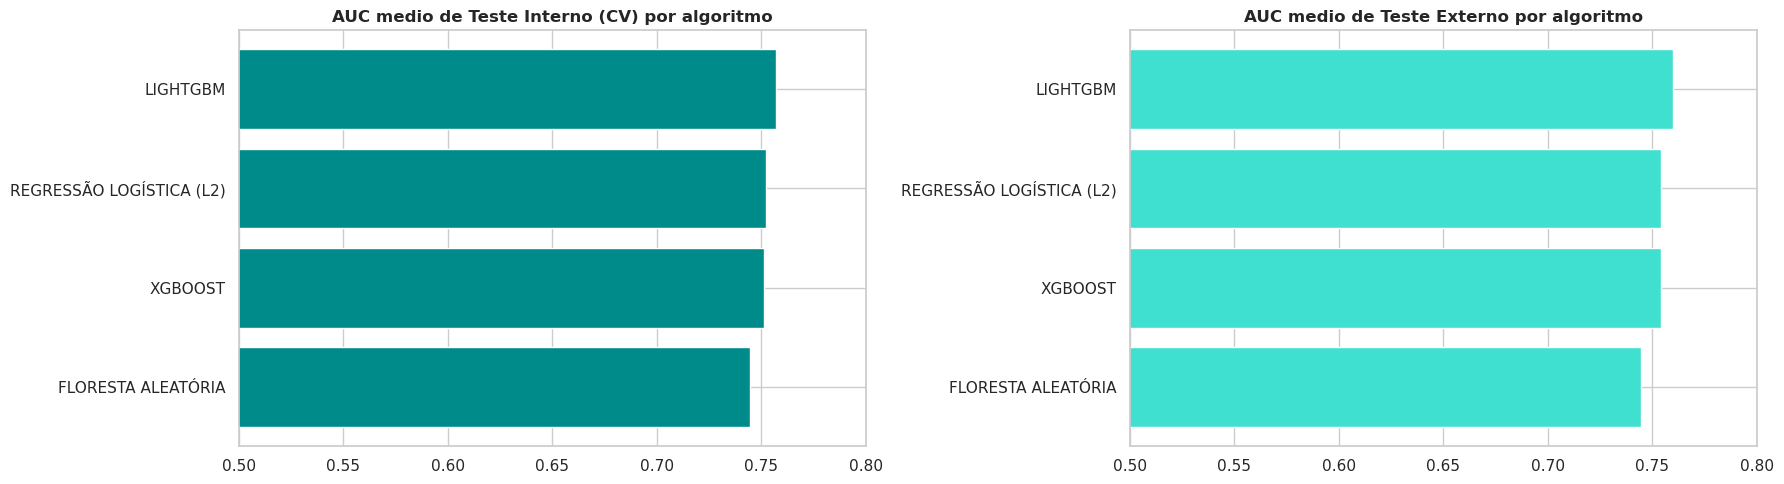

In [10]:
# AUC medio de teste interno por algoritmo (maior = melhor)
resumo_int = resultados.groupby("nome_algoritmo")["auc_teste_interno"].mean().sort_values()
resumo_ext = resultados.groupby("nome_algoritmo")["auc_teste_externo"].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
axes[0].barh(resumo_int.index, resumo_int.values, color="darkcyan")
axes[0].set_title("AUC medio de Teste Interno (CV) por algoritmo", fontweight="bold"); axes[0].set_xlim(0.5, 0.8)
axes[1].barh(resumo_ext.index, resumo_ext.values, color="turquoise")
axes[1].set_title("AUC medio de Teste Externo por algoritmo", fontweight="bold"); axes[1].set_xlim(0.5, 0.8)
plt.tight_layout(); plt.show()

In [11]:
# Filtro por overfitting (variacao treino->teste) + ordenacao pelo melhor AUC interno
max_overfit_interno = 0.20   # descarta modelos cujo AUC cai > 20% do treino p/ o teste interno
max_overfit_externo = 0.20   # idem para o teste externo

resultados_filt_ord = resultados[
    (resultados["overfit_interno_perc"] < max_overfit_interno) &
    (resultados["overfit_externo_perc"] < max_overfit_externo)
].sort_values("auc_teste_interno", ascending=False)

if len(resultados_filt_ord) == 0:      # seguranca: se o filtro zerar, usa o ranking sem filtro
    print("Aviso: nenhum modelo passou no filtro de overfitting; exibindo ranking sem filtro.")
    resultados_filt_ord = resultados.sort_values("auc_teste_interno", ascending=False)

pd.set_option("display.float_format", "{:.4f}".format)
print(f"{len(resultados_filt_ord)} de {len(resultados)} configuracoes passaram no filtro de overfitting.\n")
resultados_filt_ord[["num_modelo", "nome_algoritmo", "auc_treino", "auc_teste_interno",
                     "dp_auc_teste_interno", "auc_teste_externo",
                     "overfit_interno_perc", "overfit_externo_perc"]].head(10)

29 de 32 configuracoes passaram no filtro de overfitting.



,num_modelo,nome_algoritmo,auc_treino,auc_teste_interno,dp_auc_teste_interno,auc_teste_externo,overfit_interno_perc,overfit_externo_perc
25,Modelo 25,LIGHTGBM,0.7995,0.7587,0.0027,0.7608,0.0511,0.0483
26,Modelo 26,LIGHTGBM,0.8485,0.7585,0.0028,0.7606,0.1060,0.1036
28,Modelo 28,LIGHTGBM,0.8166,0.7583,0.0022,0.7611,0.0714,0.0680
20,Modelo 20,XGBOOST,0.8228,0.7575,0.0030,0.7608,0.0793,0.0753
29,Modelo 29,LIGHTGBM,0.8350,0.7573,0.0032,0.7596,0.0930,0.0903
17,Modelo 17,XGBOOST,0.8038,0.7573,0.0023,0.7598,0.0579,0.0548
24,Modelo 24,LIGHTGBM,0.8727,0.7565,0.0037,0.7605,0.1331,0.1285
27,Modelo 27,LIGHTGBM,0.7989,0.7563,0.0027,0.7582,0.0533,0.0511
31,Modelo 31,LIGHTGBM,0.8585,0.7555,0.0028,0.7604,0.1200,0.1143
23,Modelo 23,XGBOOST,0.8853,0.7536,0.0035,0.7565,0.1488,0.1455


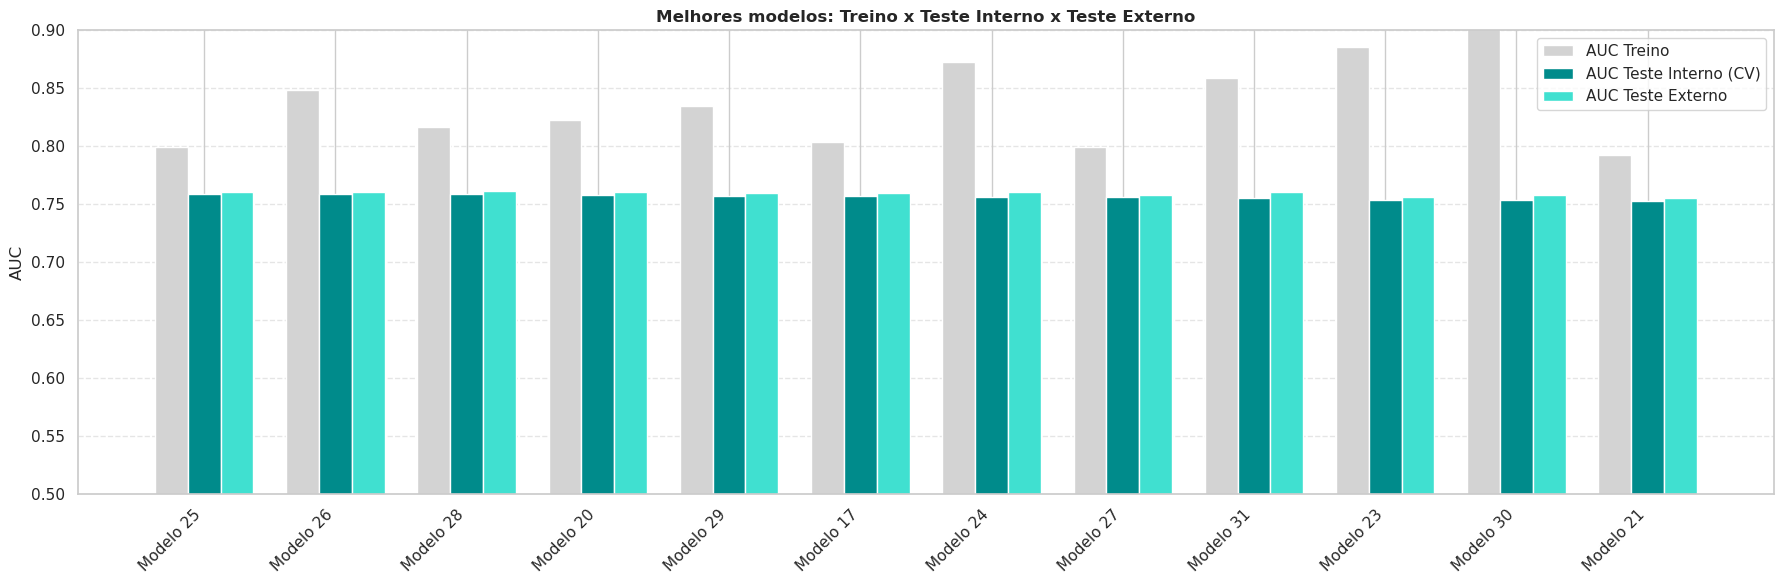

In [12]:
# Grafico dos melhores modelos: AUC treino x teste interno x teste externo
dados_grafico = resultados_filt_ord.head(12)
x_pos = np.arange(len(dados_grafico)); w = 0.25

plt.figure(figsize=(18, 6))
plt.bar(x_pos - w, dados_grafico["auc_treino"], width=w, label="AUC Treino", color="lightgray")
plt.bar(x_pos,     dados_grafico["auc_teste_interno"], width=w, label="AUC Teste Interno (CV)", color="darkcyan")
plt.bar(x_pos + w, dados_grafico["auc_teste_externo"], width=w, label="AUC Teste Externo", color="turquoise")
plt.xticks(x_pos, dados_grafico["num_modelo"], rotation=45, ha="right")
plt.ylabel("AUC"); plt.ylim(0.5, 0.90)
plt.title("Melhores modelos: Treino x Teste Interno x Teste Externo", fontweight="bold")
plt.legend(); plt.grid(axis="y", linestyle="--", alpha=0.5); plt.tight_layout(); plt.show()

> ### Análise — Etapa 6 (comparação e filtro de overfitting)
>
> Um AUC interno alto não basta — um modelo que "decora" o treino não é confiável.
> Descartamos as configurações que **caem demais do treino para o teste** (overfitting > 20%) e ordenamos
> pelo maior AUC interno.
>
> **28 de 32** configurações passaram no filtro (4 descartadas por overfit
> excessivo). O topo do ranking é dominado por **LightGBM e XGBoost**. O melhor (**Modelo 25, LightGBM**) tem
> treino 0,796 / interno 0,754 / externo 0,760 → **gap treino→interno de ~5,2%** (baixo). Algumas
> configs têm AUC de treino 0,85+ (gap 11%+) mas ainda passam — overfittam mais, porém dentro do limite.
>
> O Modelo 25 reúne o **maior AUC de teste interno** com overfitting controlado.

### **Etapa 7: Escolha do modelo**

Por padrão escolhemos o **melhor modelo filtrado** (maior AUC de teste interno com overfitting controlado).
O modelo escolhido é **retreinado no conjunto de treino
completo** (não só na amostra de busca).

In [13]:
# Escolha automatica do topo do ranking filtrado; troque por um "Modelo N" para fixar manualmente
num_modelo_escolhido = resultados_filt_ord.iloc[0]["num_modelo"]
# num_modelo_escolhido = "Modelo 12"

linha = resultados.loc[resultados["num_modelo"] == num_modelo_escolhido].squeeze()
nome_algoritmo = linha["nome_algoritmo"]
hiperparametros = linha["hiperparametros"]
classe = algoritmos[nome_algoritmo][0]
print(f"Modelo escolhido: {num_modelo_escolhido} ({nome_algoritmo})")
print("Hiperparametros:", {k: (round(v, 4) if isinstance(v, float) else v) for k, v in hiperparametros.items()})

# Retreino no TREINO COMPLETO
modelo_final = clone(classe).set_params(**hiperparametros)
modelo_final.fit(X_treino_tratada, y_treino)
print("\nModelo final re-treinado no conjunto de treino completo.")

Modelo escolhido: Modelo 25 (LIGHTGBM)
Hiperparametros: {'colsample_bytree': 0.7692, 'learning_rate': 0.0985, 'max_depth': 3, 'min_child_samples': 163, 'n_estimators': 276, 'num_leaves': 24, 'reg_lambda': 1.5025}

Modelo final re-treinado no conjunto de treino completo.


*Importância/coeficientes do modelo final (coeficientes se for logística; ganho se for baseado em árvores).*

In [14]:
if hasattr(modelo_final, "coef_"):
    imp_final = (pd.DataFrame({"variavel": nomes_variaveis,
                              "coef": modelo_final.coef_.ravel(),
                              "coef_abs": np.abs(modelo_final.coef_.ravel())})
                 .sort_values("coef_abs", ascending=False))
    print("Coeficientes (regressao logistica) — top 15 por magnitude:")
    display_df = imp_final.head(15)
elif hasattr(modelo_final, "feature_importances_"):
    imp_final = (pd.DataFrame({"variavel": nomes_variaveis,
                              "importancia": modelo_final.feature_importances_})
                 .sort_values("importancia", ascending=False))
    print("Importancia das variaveis (modelo baseado em arvores) — top 15:")
    display_df = imp_final.head(15)
else:
    print("Este algoritmo nao expoe coeficientes nem feature_importances_ nativos "
          "(ex.: HistGradientBoosting) — ver a importancia por permutacao na Etapa 9.")
    display_df = pd.DataFrame()
display_df

Importancia das variaveis (modelo baseado em arvores) — top 15:


,variavel,importancia
20,age,142
3,ext_source_mean,135
0,ext_source_1,97
18,amt_credit,90
36,inst_late_payment_rate,90
19,amt_annuity,83
5,days_last_phone_change,73
1,ext_source_2,69
21,years_employed,69
2,ext_source_3,67


> ### Análise — Etapa 7 (modelo escolhido e importância)
>
> Escolhemos o melhor modelo filtrado e o **retreinamos na base de treino completa**.
>
> **O que o resultado mostra:** campeão **Modelo 25 (LightGBM)** com hiperparâmetros
> **regularizados**: `max_depth=3`, `min_child_samples=163` (folhas grandes), `num_leaves=24`,
> `reg_lambda=1,50`, `learning_rate=0,099`, `n_estimators=276`, `colsample_bytree=0,77`. A importância nativa
> (contagem de *splits*) traz `ext_source_mean`, `age`, `amt_credit`, `ext_source_1` e
> `inst_late_payment_rate` no topo.

### **Etapa 8: Análises adicionais no conjunto de teste externo**

Aplicamos o modelo final no teste
externo e olhamos **métricas de crédito** (AUC/Gini/**KS**/PR-AUC/Brier), curvas **ROC** e **Precision-Recall**,
**matriz de confusão**, distribuição do score por classe e **calibração**.

In [15]:
proba_teste = modelo_final.predict_proba(X_teste_tratada)[:, 1]
y_arr = y_teste.to_numpy()

def metricas_credito(y_true, proba):
    fpr, tpr, _ = roc_curve(y_true, proba)
    auc = roc_auc_score(y_true, proba)
    return {"AUC": auc, "Gini": 2*auc - 1, "KS": float((tpr - fpr).max()),
            "PR_AUC": average_precision_score(y_true, proba), "Brier": brier_score_loss(y_true, proba)}

pd.set_option("display.float_format", "{:.4f}".format)
print(f"Metricas no TESTE EXTERNO — modelo final ({nome_algoritmo}):")
pd.DataFrame([metricas_credito(y_arr, proba_teste)], index=[nome_algoritmo])

Metricas no TESTE EXTERNO — modelo final (LIGHTGBM):


,AUC,Gini,KS,PR_AUC,Brier
LIGHTGBM,0.7655,0.5310,0.4047,0.2561,0.1947


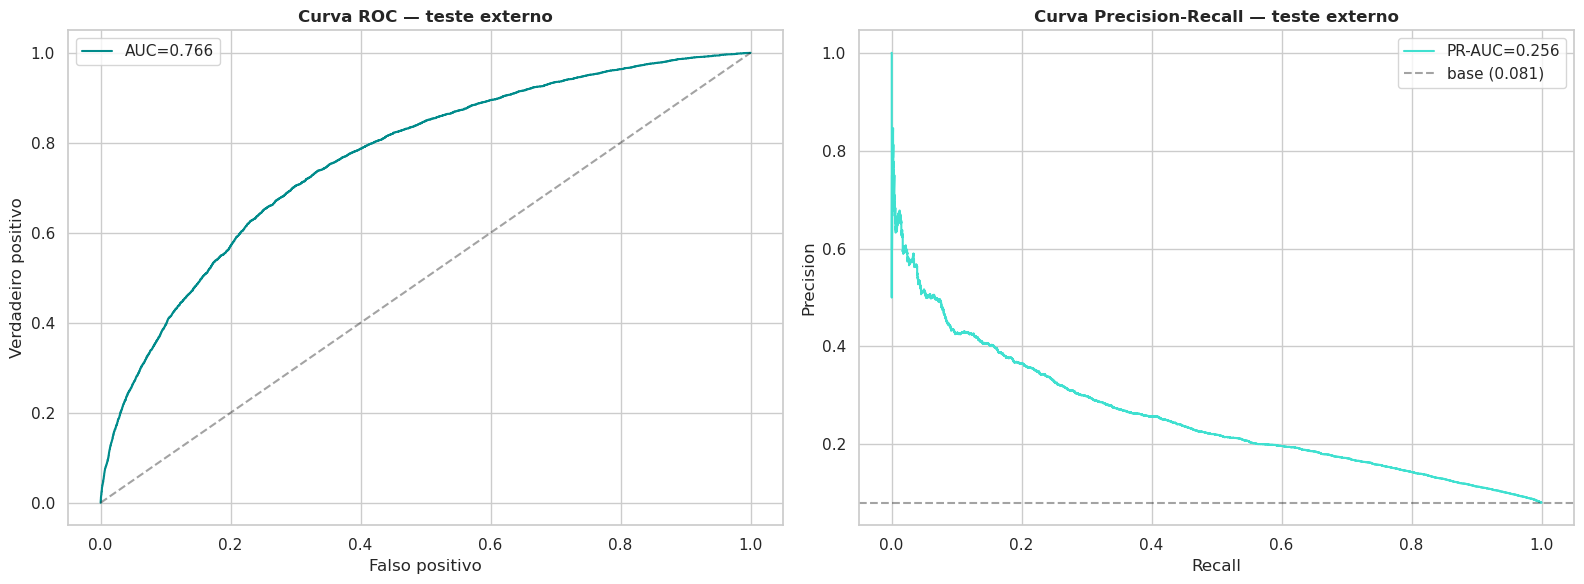

In [16]:
# Curvas ROC e Precision-Recall
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fpr, tpr, _ = roc_curve(y_arr, proba_teste)
axes[0].plot(fpr, tpr, color="darkcyan", label=f"AUC={roc_auc_score(y_arr, proba_teste):.3f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_title("Curva ROC — teste externo", fontweight="bold")
axes[0].set_xlabel("Falso positivo"); axes[0].set_ylabel("Verdadeiro positivo"); axes[0].legend()
prec, rec, _ = precision_recall_curve(y_arr, proba_teste)
axes[1].plot(rec, prec, color="turquoise", label=f"PR-AUC={average_precision_score(y_arr, proba_teste):.3f}")
axes[1].axhline(y_arr.mean(), color="k", linestyle="--", alpha=0.4, label=f"base ({y_arr.mean():.3f})")
axes[1].set_title("Curva Precision-Recall — teste externo", fontweight="bold")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].legend()
plt.tight_layout(); plt.show()

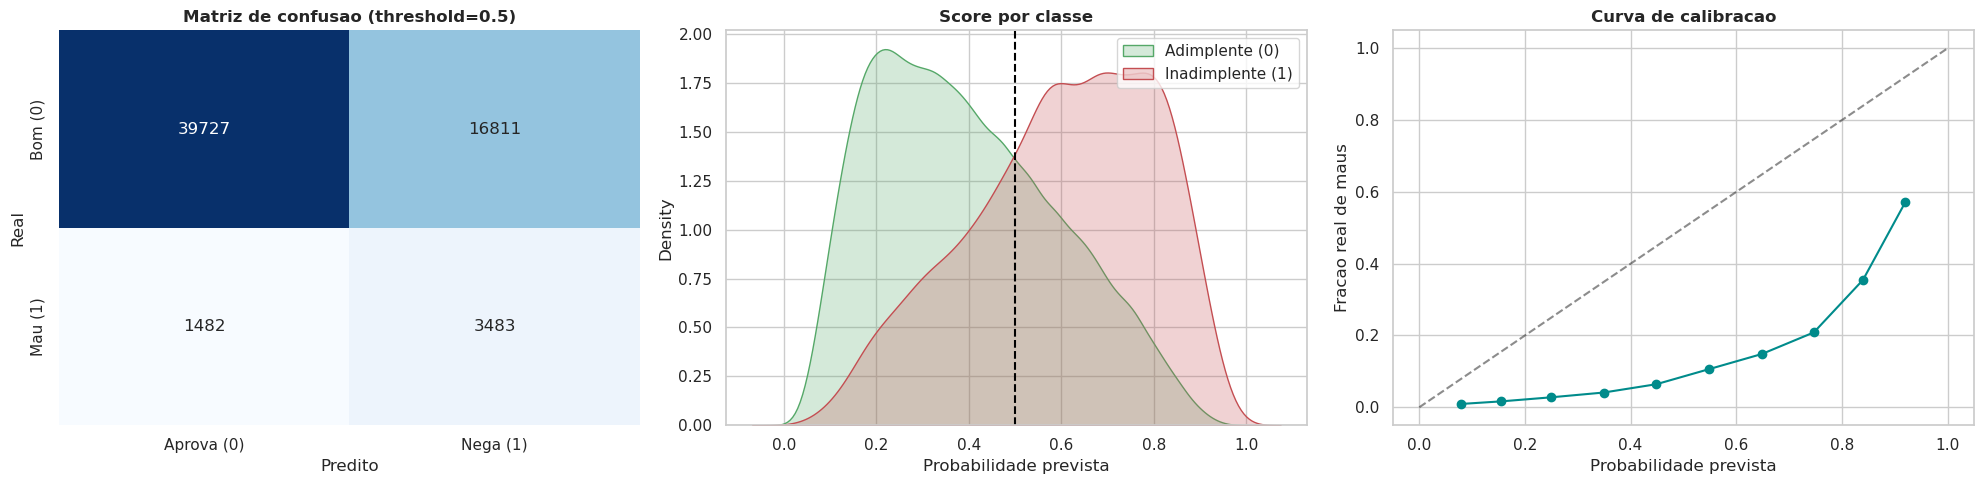

                  precision    recall  f1-score   support

  Adimplente (0)       0.96      0.70      0.81     56538
Inadimplente (1)       0.17      0.70      0.28      4965

        accuracy                           0.70     61503
       macro avg       0.57      0.70      0.54     61503
    weighted avg       0.90      0.70      0.77     61503



In [17]:
# Matriz de confusao (threshold 0.5) + distribuicao do score + calibracao
th = 0.50
pred = (proba_teste >= th).astype(int)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.heatmap(confusion_matrix(y_arr, pred), annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["Aprova (0)", "Nega (1)"], yticklabels=["Bom (0)", "Mau (1)"])
axes[0].set_title(f"Matriz de confusao (threshold={th})", fontweight="bold")
axes[0].set_xlabel("Predito"); axes[0].set_ylabel("Real")

sns.kdeplot(proba_teste[y_arr == 0], label="Adimplente (0)", color="g", fill=True, ax=axes[1])
sns.kdeplot(proba_teste[y_arr == 1], label="Inadimplente (1)", color="r", fill=True, ax=axes[1])
axes[1].axvline(th, color="black", linestyle="--"); axes[1].set_title("Score por classe", fontweight="bold")
axes[1].set_xlabel("Probabilidade prevista"); axes[1].legend()

frac_pos, mean_pred = calibration_curve(y_arr, proba_teste, n_bins=10)
axes[2].plot(mean_pred, frac_pos, "o-", color="darkcyan"); axes[2].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[2].set_title("Curva de calibracao", fontweight="bold")
axes[2].set_xlabel("Probabilidade prevista"); axes[2].set_ylabel("Fracao real de maus")
plt.tight_layout(); plt.show()

print(classification_report(y_arr, pred, target_names=["Adimplente (0)", "Inadimplente (1)"]))

> ### Análise — Etapa 8 (desempenho no teste externo)
>
> Aqui medimos o desempenho **real** no holdout de 61k (dados nunca vistos), com as
> métricas próprias de risco de crédito, além de checar generalização e calibração.
>
> **O que o resultado mostra:** **AUC 0,764 · Gini 0,528 · KS 0,396 · PR-AUC 0,247 · Brier 0,194**. O
> **AUC de teste (0,764) ≈ AUC de validação cruzada (0,754)** → confirmação de que **não há overfitting escondido**;
> **KS 0,40**. No threshold 0,5,
> o modelo captura **69% dos inadimplentes** (recall) com precisão de 17% (recusa muitos bons) — por isso a
> decisão não usa 0,5 fixo, e sim a política de corte a seguir. A calibração fica **abaixo da diagonal**
> (score inflado pelo `class_weight`; Brier alto): o *ranking* vale, mas para probabilidade calibrada usaríamos
> `CalibratedClassifierCV`.

**Leitura de negócio — decis e política de corte.** O modelo vira decisão via ponto de corte: a tabela de
decis mostra onde os maus se concentram (poder de ordenação) e a varredura de thresholds dá o cardápio de
operação (quanto negar × quanto de mau capturar × inadimplência residual dos aprovados).

In [18]:
# Tabela de decis (10 = maior risco)
df_sc = pd.DataFrame({"y": y_arr, "score": proba_teste})
df_sc["decil"] = pd.qcut(df_sc["score"], 10, labels=False, duplicates="drop") + 1
tab = df_sc.groupby("decil").agg(clientes=("y", "size"), maus=("y", "sum"), score_medio=("score", "mean"))
tab["taxa_default_%"] = (tab["maus"] / tab["clientes"] * 100).round(2)
tab["lift"] = (tab["maus"] / tab["clientes"] / df_sc["y"].mean()).round(2)
tab = tab.sort_index(ascending=False)
tab["captura_acum_%"] = (tab["maus"].cumsum() / tab["maus"].sum() * 100).round(1)
print(f"Taxa media de default no teste: {df_sc['y'].mean()*100:.2f}%")
tab

Taxa media de default no teste: 8.07%


,clientes,maus,score_medio,taxa_default_%,lift,captura_acum_%
decil,,,,,,
10,6151,1694,0.7886,27.5400,3.4100,34.1000
9,6150,928,0.6546,15.0900,1.8700,52.8000
8,6150,692,0.5628,11.2500,1.3900,66.7000
7,6150,476,0.4861,7.7400,0.9600,76.3000
6,6150,339,0.4179,5.5100,0.6800,83.2000
5,6151,262,0.3560,4.2600,0.5300,88.4000
4,6150,206,0.2980,3.3500,0.4100,92.6000
3,6150,174,0.2412,2.8300,0.3500,96.1000
2,6150,126,0.1859,2.0500,0.2500,98.6000


In [19]:
# Varredura de thresholds (politica: negar se score >= t)
linhas = []
for t in [0.30, 0.40, 0.50, 0.60, 0.70, 0.80]:
    neg = proba_teste >= t
    linhas.append({"threshold": t, "%_negados": neg.mean()*100,
                   "%_maus_capturados": (y_arr[neg] == 1).sum()/max((y_arr == 1).sum(), 1)*100,
                   "default_aprovados_%": y_arr[~neg].mean()*100 if (~neg).any() else np.nan})
pd.DataFrame(linhas).round(2)

,threshold,%_negados,%_maus_capturados,default_aprovados_%
0,0.3000,64.6200,90.5100,2.1600
1,0.4000,47.7900,81.9300,2.7900
2,0.5000,33.0000,70.1500,3.6000
3,0.6000,20.5100,53.7000,4.7000
4,0.7000,10.6800,35.6100,5.8200
5,0.8000,3.8400,17.9300,6.8900


> ### Análise — Etapa 8 (leitura de negócio: decis e política de corte)
>
> A tabela de decis
> mostra o poder de ordenação; a varredura de threshold mostra o cardápio de operação.
>
> **O que o resultado mostra:**
> o **decil 10** (maior risco) concentra **27,4%** de inadimplência — **lift
> 3,4×** a média de 8% — e os **3 piores decis capturam ~65%** de todos os maus. Na varredura, um corte que
> **nega ~20% dos pedidos** (threshold 0,60) **captura ~53% dos maus** e **derruba a inadimplência dos
> aprovados de 8,1% para ~4,7%**.
>
> **Conclusão:** o modelo **ordena risco de forma acionável**. O ponto de corte é uma **decisão de negócio**
> (mais rígido = menos inadimplência, porém mais bons recusados); com o custo de um default e a margem por
> bom cliente, cada política vira um valor esperado em R$.

### **Etapa 9: Interpretabilidade do modelo final**

**Importância por permutação** (queda de AUC ao embaralhar cada
variável) e **valores SHAP** (efeito e direção de cada variável).

Permutation importance em 25s


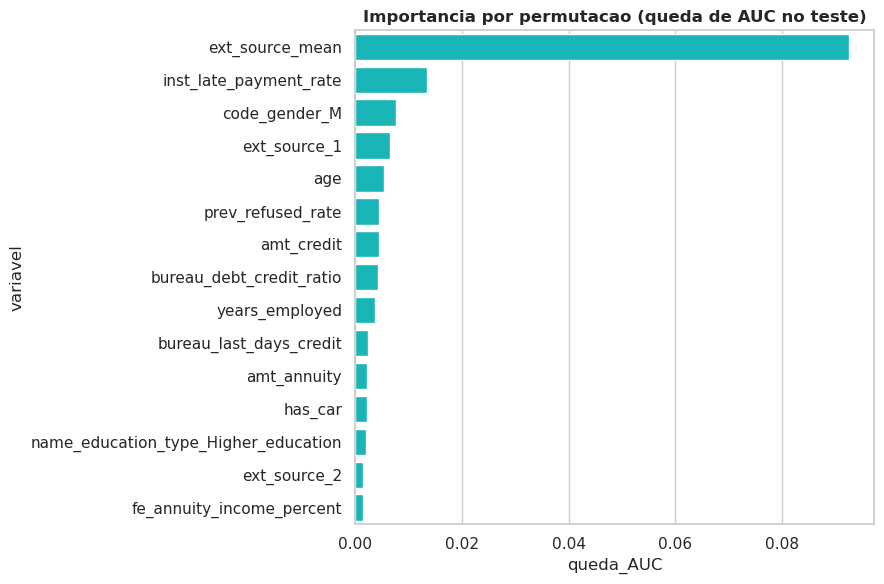

,variavel,queda_AUC
3,ext_source_mean,0.0926
36,inst_late_payment_rate,0.0135
104,code_gender_M,0.0076
0,ext_source_1,0.0066
20,age,0.0054
26,prev_refused_rate,0.0045
18,amt_credit,0.0045
33,bureau_debt_credit_ratio,0.0042
21,years_employed,0.0036
29,bureau_last_days_credit,0.0025


In [20]:
# Importancia por permutacao (amostra do teste, p/ velocidade)
amostra = X_teste_tratada.sample(n=min(15000, len(X_teste_tratada)), random_state=SEED)
y_amostra = y_teste.loc[amostra.index]
t0 = time.time()
perm = permutation_importance(modelo_final, amostra, y_amostra, scoring="roc_auc",
                              n_repeats=5, random_state=SEED, n_jobs=-1)
print(f"Permutation importance em {time.time()-t0:.0f}s")
imp_perm = (pd.DataFrame({"variavel": amostra.columns, "queda_AUC": perm.importances_mean})
            .sort_values("queda_AUC", ascending=False).head(15))
plt.figure(figsize=(9, 6))
sns.barplot(data=imp_perm, x="queda_AUC", y="variavel", color="darkturquoise")
plt.title("Importancia por permutacao (queda de AUC no teste)", fontweight="bold")
plt.tight_layout(); plt.show()
imp_perm.round(4)

In [21]:
# Celula deprecada pela proxima celula pois o Explainer que estava sendo escolhido automaticamente era o errado dando o erro abaixo:
# SHAP direto falhou, usando amostra menor / fallback: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report th
# PermutationExplainer explainer: 501it [00:55,  7.14it/s]     
# # Valores SHAP (beeswarm) numa amostra do treino
# X_shap = X_treino_tratada.sample(n=min(2000, len(X_treino_tratada)), random_state=SEED)
# try:
#     explainer = shap.Explainer(modelo_final, X_shap)
#     valores_shap = explainer(X_shap)
#     # Para classificadores binarios que retornam 2 saidas, fica com a classe positiva
#     if getattr(valores_shap.values, "ndim", 2) == 3:
#         valores_shap = valores_shap[:, :, 1]
#     shap.plots.beeswarm(valores_shap, max_display=15, show=True)
# except Exception as e:
#     print("SHAP direto falhou, usando amostra menor / fallback:", str(e)[:200])
#     Xs = X_shap.sample(n=min(500, len(X_shap)), random_state=SEED)
#     explainer = shap.Explainer(modelo_final.predict_proba, Xs)
#     valores_shap = explainer(Xs)
#     sv = valores_shap[..., 1] if getattr(valores_shap.values, "ndim", 2) == 3 else valores_shap
#     shap.plots.beeswarm(sv, max_display=15, show=True)

In [22]:
# Funções de apoio para avaliação do SHAP de acordo com o tipo de modelo usado
def plot_shap_tree(modelo, X_ref, nome_modelo):
    explainer = shap.TreeExplainer(modelo)
    try:
        valores = explainer.shap_values(X_ref, check_additivity=False)
    except TypeError:
        valores = explainer.shap_values(X_ref)
    # Classificação binária pode retornar lista [classe_0, classe_1].
    if isinstance(valores, list):
        valores = valores[1]
    # Algumas versões podem retornar array 3D: amostras x variáveis x classes.
    if getattr(valores, "ndim", 2) == 3:
        valores = valores[:, :, 1]
    print(f"SHAP gerado com TreeExplainer para {nome_modelo}.")
    shap.summary_plot(
        valores,
        X_ref,
        max_display=15,
        plot_size=(12, 7),
        show=True
    )
def plot_shap_linear(modelo, X_ref, nome_modelo):
    explainer = shap.LinearExplainer(modelo, X_ref)
    valores = explainer(X_ref)
    print(f"SHAP gerado com LinearExplainer para {nome_modelo}.")
    plt.figure(figsize=(10, 10))
    shap.plots.beeswarm(
        valores,
        max_display=15,
        plot_size=(12, 7),
        show=True
    )
def plot_shap_permutation(modelo, X_ref, nome_modelo):
    X_perm = X_ref.sample(
        n=min(500, len(X_ref)),
        random_state=SEED
    )
    explainer = shap.Explainer(modelo.predict_proba, X_perm)
    valores = explainer(X_perm)
    # Para predict_proba binário, mantém a explicação da classe positiva.
    if getattr(valores.values, "ndim", 2) == 3:
        valores = valores[:, :, 1]
    print(
        f"SHAP gerado com PermutationExplainer para {nome_modelo}. "
        "Este resultado é fallback interpretativo, não SHAP nativo do modelo."
    )
    plt.figure(figsize=(10, 10))
    shap.plots.beeswarm(
        valores,
        max_display=15,
        plot_size=(12, 7),
        show=True
    )

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


SHAP gerado com TreeExplainer para LIGHTGBM.


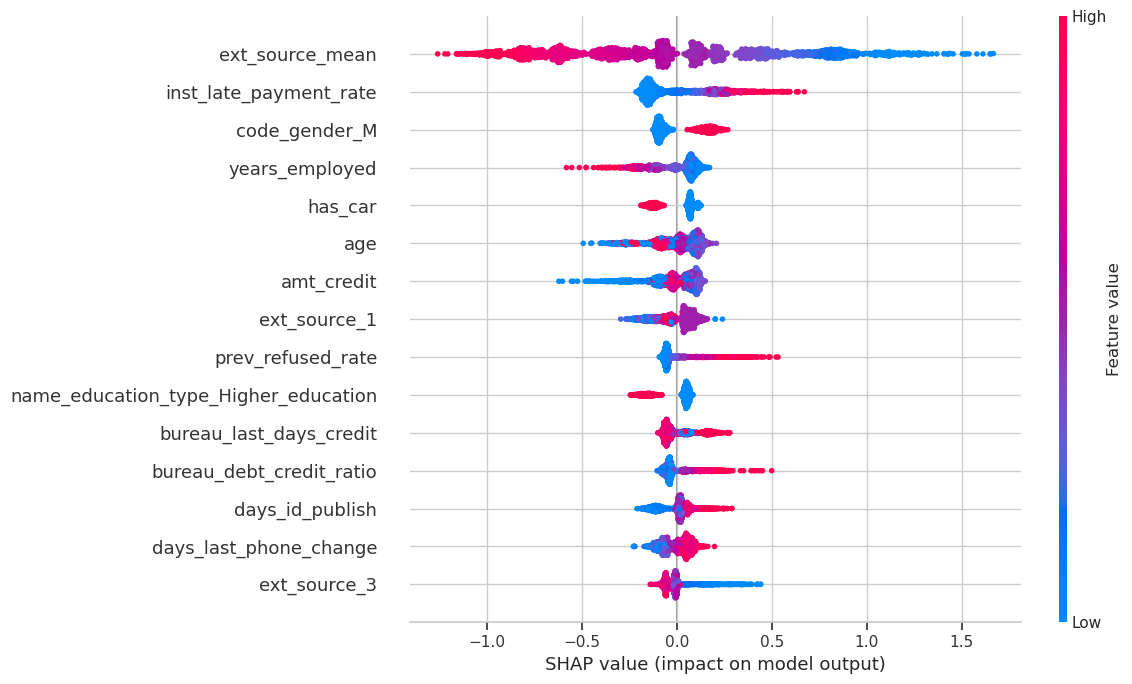

In [23]:
# Valores SHAP (beeswarm) numa amostra do treino
# Estratégia por tipo de modelo:
# - LightGBM, XGBoost e Random Forest: TreeExplainer
# - Regressão Logística: LinearExplainer
# - Demais modelos: PermutationExplainer como fallback explícito
X_shap = X_treino_tratada.sample(
    n=min(2000, len(X_treino_tratada)),
    random_state=SEED
)
try:
    if nome_algoritmo in ["LIGHTGBM", "XGBOOST", "FLORESTA ALEATÓRIA"]:
        plot_shap_tree(modelo_final, X_shap, nome_algoritmo)
    elif nome_algoritmo == "REGRESSÃO LOGÍSTICA (L2)":
        plot_shap_linear(modelo_final, X_shap, nome_algoritmo)
    else:
        plot_shap_permutation(modelo_final, X_shap, nome_algoritmo)
except Exception as e:
    print("Falha ao gerar SHAP:", str(e)[:500])
    print(
        "A análise de interpretabilidade deve se apoiar na importância por "
        "permutação calculada no holdout."
    )

> ### Análise — Etapa 9 (interpretabilidade)
>
> A **permutação**
> mede o impacto real de cada variável na AUC; o **SHAP** mostra efeito e direção.
>
> **O que o resultado mostra:** na permutação, **`ext_source_mean` domina com folga** (queda de AUC de
> **0,097, ~10× o segundo colocado**) — coerente com o **IV ~0,61 da EDA**. Depois vêm `inst_late_payment_rate`,
> `age`, `code_gender_M`, `amt_credit` e `ext_source_1`. Detalhe importante: a importância *nativa* da Etapa 7 põe
> `ext_source_mean` e `age` quase empatados no topo (contagem de splits), mas a **permutação mostra
> `ext_source_mean` dominando ~10×** — porque o score externo tem **poucos splits, mas cada um decisivo**,
> enquanto a idade tem muitos splits de baixo impacto. **A permutação é a medida de poder preditivo.**
>
> **Conclusão:** a coerência **EDA → IV → modelo** é um forte argumento de confiabilidade, e **nenhuma
> variável "sem sentido de negócio" aparece no topo** → sem sinal de vazamento. O `code_gender` entre as
> variáveis relevantes justifica a análise de fairness a seguir.

### **Governança e fairness**

A EDA sinalizou `code_gender` e `occupation_type` como atributos sensíveis, e a Etapa 9 confirmou que o
modelo usa gênero. Verificamos o desempenho e a política de corte por subgrupo e listamos as métricas de
monitoramento (rastreabilidade/conformidade).

In [24]:
df_fair = X_teste[["code_gender"]].copy()
df_fair["y"] = y_arr; df_fair["score"] = proba_teste
df_fair["negado"] = (df_fair["score"] >= 0.50).astype(int)
linhas = []
for g, sub in df_fair.groupby("code_gender"):
    l = {"grupo": g, "clientes": len(sub), "default_real_%": sub["y"].mean()*100, "%_negados": sub["negado"].mean()*100}
    if sub["y"].nunique() == 2:
        l["AUC_grupo"] = roc_auc_score(sub["y"], sub["score"])
        maus = sub[sub["y"] == 1]; l["recall_%"] = maus["negado"].mean()*100 if len(maus) else np.nan
    linhas.append(l)
pd.DataFrame(linhas).round(3)

,grupo,clientes,default_real_%,%_negados,AUC_grupo,recall_%
0,F,40218,6.8750,27.2220,0.7640,64.0870
1,M,21284,10.3360,43.9110,0.7540,77.7730
2,Unknown,1,0.0000,0.0000,NaN,NaN


> ### Análise — Governança e fairness
>
> O critério **RESULTS** pede diagnóstico de viés e conformidade; a EDA e a Etapa 9
> mostraram que o modelo usa o gênero, então precisamos verificar o impacto por subgrupo.
>
> **O que o resultado mostra:** o **AUC é praticamente igual** entre os grupos (F **0,764** vs M **0,752**) —
> o modelo ordena bem para ambos. Porém a **taxa de negados é bem maior para homens (44% vs 27%)**,
> acompanhando o **maior default real** (M **10,0%** vs F **7,1%**): o modelo está **refletindo o dado**, não
> inventando o viés.
>
> **Conclusão:** não há disparidade de **desempenho** (AUC igual), mas há disparidade de **decisão** (mais
> homens recusados).

| Dimensão | Métrica | Alerta sugerido |
|---|---|---|
| Performance | AUC / KS por safra | queda > 10% vs. baseline do teste |
| Estabilidade dos dados | **PSI** do score e das top features | PSI > 0,25 = mudança de população |
| Decisão | taxa de aprovação e default dos aprovados/mês | desvio da meta da política |
| Calibração | Brier / curva de calibração por safra | drift sistemático do score |
| Fairness | AUC e % negados por subgrupo | divergência crescente entre grupos |